## Task 1 - Data Retrieval
I retrieved one s2 resolutioon slice each from hela-2 and hela-3.

In [1]:
import fsspec, zarr, s3fs
import dask.array as da 



def obtain_data_slice(dataset = "jrc_hela-2"): #Returns one s2 resolution slice
    
    fs = s3fs.S3FileSystem(anon=True, client_kwargs={"region_name": "us-east-1"})
    group = zarr.open(zarr.N5FSStore('s3://janelia-cosem-datasets/'+ dataset + '/'+ dataset + '.n5', anon=True, client_kwargs = {"region_name": "us-east-1"})) # access the root of the n5 container
    zdata = group['em/fibsem-uint16/s2'] # s0 is the the full-resolution data for this particular volume
    
    ddata = da.from_array(zdata, chunks=zdata.chunks)
    
    result = ddata[400:401].compute()
    return result

In [2]:
hela2 = obtain_data_slice(dataset = "jrc_hela-2")
hela3 = obtain_data_slice(dataset = "jrc_hela-3")

/tmp/ipykernel_392115/3801774416.py:9: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  group = zarr.open(zarr.N5FSStore('s3://janelia-cosem-datasets/'+ dataset + '/'+ dataset + '.n5', anon=True, client_kwargs = {"region_name": "us-east-1"})) # access the root of the n5 container


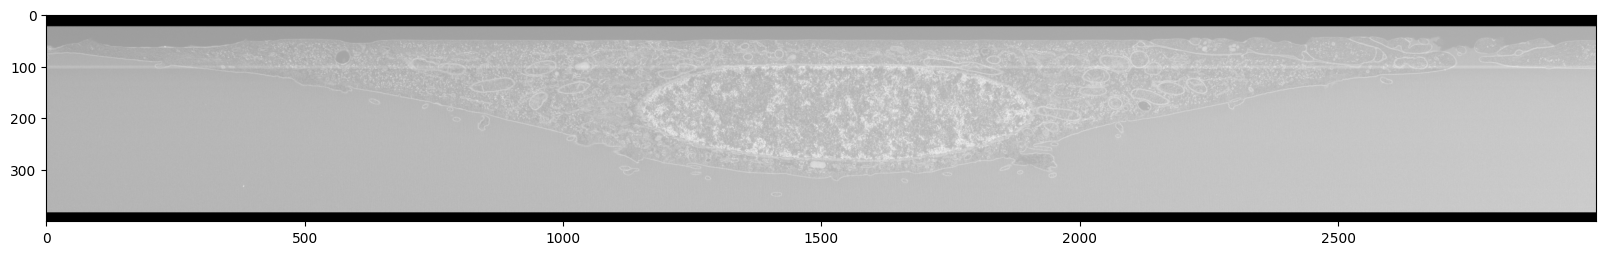

In [30]:
#Visualizing hela2
import matplotlib.pyplot as plt
import numpy as np

vmin, vmax = hela2.min(), hela2.max()
fig= plt.figure(figsize=(20, 12))
#clipped = np.clip(result, vmin, vmax)
normalized = ((hela2 - vmin) / (vmax - vmin) * 255).astype(np.uint8)
plt.imshow(normalized[0], cmap='gray')

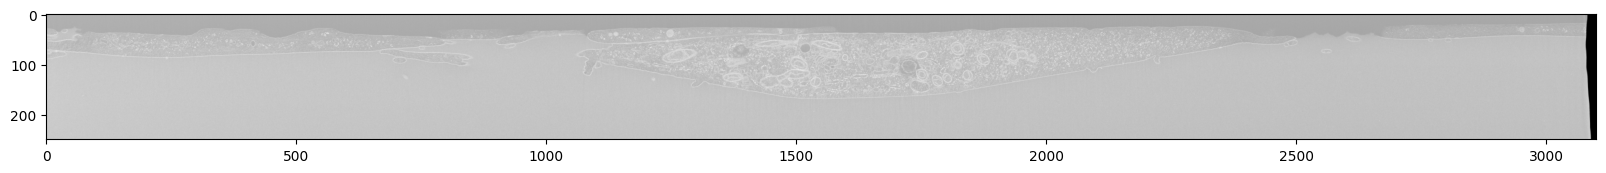

In [4]:
#Visualizing hela3
import matplotlib.pyplot as plt
import numpy as np

vmin, vmax = hela3.min(), hela3.max()
fig= plt.figure(figsize=(20, 12))
#clipped = np.clip(result, vmin, vmax)
normalized = ((hela3 - vmin) / (vmax - vmin) * 255).astype(np.uint8)
plt.imshow(normalized[0], cmap='gray')

## Task 2 — Feature Extraction with DINO
I used Dino-V2 from HuggingFace to obtain image embeddings.

**Patch size selection:** Patch size selection is dependent on how fine-grained we want the embeddings to be. Since we want embeddings that can capture the ultrastructure of the mitochondria, having smaller patches would be better. However, if the patches are too small, then we don't capture enough context per patch. Therefore, having 2x2 to 5x5 patches (depending on patch and mitochondria shapes) per mitochondrion would give us a good balance between having enough pixels per patch for context and enough granularity to capture fine-grained structure. 

Mitochondria size is approximately between 0.5 - 1 micron in width and 1 - 10 microns in length. For s2, the pixel resolution in the XY plane is 16 nanometer. Therefore the size of mitochondria is between 32 to 64 pixels in width and 64 to 640 pixels in length. Therefore, if we use square patches, a size of 8-16 pixels would work well. Furthermore, since dinov2 is already pretrained on patches of size 14x14 pixels, I also decided to keep the patch size to 14x14.

In [5]:
from transformers import AutoImageProcessor, AutoModel
import torch

def obtain_embeddings(result, pretrained_model_name = "facebook/dinov2-base"):

    processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
    model = AutoModel.from_pretrained(
        pretrained_model_name 
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    inputs = (result - result.min()) / (result.max() - result.min())
    inputs = np.stack([inputs, inputs, inputs], axis=1)
    
    with torch.inference_mode():
        outputs = model(torch.from_numpy(inputs))

    return outputs[0]

In [6]:
hela2_emb = obtain_embeddings(hela2)
hela3_emb = obtain_embeddings(hela3)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

/users/ajain59/.conda/envs/HHMI/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

**Dense embeddings:** To obtain dense embeddings, one method is to take the patch embeddings and try to upsample the patch embeddings to the same size as the input image. To do this, I used pytorch's interpolate function to obtain the dense embeddings as shown below.

In [7]:
from torch.nn.functional import interpolate
def obtain_dense_embeddings(embeddings, inputs):
    embeddings = embeddings[:, 1:]
    embeddings = torch.transpose(embeddings, 1, 2)
    H = inputs.shape[1]//14
    W = inputs.shape[2]//14
    embeddings = torch.reshape(embeddings, (1, embeddings.shape[1], H, W))
    dense_embeddings = interpolate(embeddings, (inputs.shape[1], inputs.shape[2]))
    return dense_embeddings


In [8]:
hela2_dense_emb = obtain_dense_embeddings(hela2_emb, hela2)
print(hela2_dense_emb.shape)

torch.Size([1, 768, 400, 3000])


## Task 3 — Embedding-Based Retrieval & Visualization
**Within-dataset and cross-dataset retrieval:** I found the embeddings corresponding to a single mitochondrion in each dataset (hela2 and hela3).

The embeddings within each dataset are more similar to each other than those across datasets. As seen in the PCA visualization below, the embeddings for both datasets could be clustered separately, rather cleanly.

However, since these datasets are similar, the cross-dataset differences in the embeddings are not very large. We can see that the embeddings show some overlap, and the embedding clusters for both datasets would be very close to each other.

**Multiple queries:** If we had multiple mitochondria per dataset, we could still use a similar PCA/UMAP/tSNE visualization for comparison. If there are few enough mitochondria, all the embeddings from each mitochondria could have separate colors to distinguish them. If there are too many query mitochondria, we could then give all mitochondria embeddings from the same dataset the same colors to get a more dataset-level comparison.

I would still expect the embeddings of mitochondria within the same dataset to be visually closer to each other than those from different datasets. 

In [47]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
hela2_emb_pca = pca.fit_transform(hela2_emb[0])
hela3_emb_pca = pca.fit_transform(hela3_emb[0])

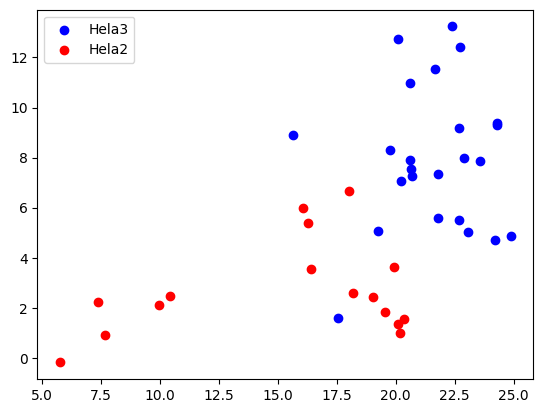

In [46]:
#Mitochondrion from Hela-3
n_w = hela3.shape[2] // 14
for i, row in enumerate(range(4, 8)):
    for j, col in enumerate(range(87, 93)):
        idx = row * n_w + col + 1
        plt.scatter(hela3_emb_pca[idx, 0], hela3_emb_pca[idx, 1], 
                    color='b', label='Hela3' if (i == 0 and j == 0) else None)
        
#Mitochondrion from Hela-2
n_w = hela2.shape[2] // 14
for i, row in enumerate(range(8, 10)):
    for j, col in enumerate(range(57, 65)):
        idx = row * n_w + col + 1
        plt.scatter(hela2_emb_pca[idx, 0], hela2_emb_pca[idx, 1], 
                    color='r', label='Hela2' if (i == 0 and j == 0) else None)

plt.legend()

## Task 4 — Proposal: Improving Mitochondria Detection with Minimal Fine-Tuning

The ideal technique for fine-tuning the model with minimal weights is LoRA, since it updates only the low-rank approximation of the update weights. We can set the fine-tuning task to be masked modeling and use LoRA to update the weights of the pre-trained model to be more accurate for any given dataset. To further reduce the space utilized for fine-tuning, we can also use Quantized LoRA (QLoRA).

Once we train the new fine-tuned model, we can use the encoder to obtain new patch embeddings for any required task. The supervised training details is dependant on the task. For example, the most efficient method to classify whether a mitochondrion is present is to obtain the CLS embeddings and train a linear probe.